In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from summarytools import dfSummary
from skimpy import skim
import statsmodels.api as sm
from scipy.stats import pearsonr
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import roc_auc_score
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler, NearMiss
from sklearn.metrics import recall_score, roc_auc_score, accuracy_score
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.model_selection import RandomizedSearchCV
from imblearn.combine import SMOTETomek
from collections import Counter
from sklearn.ensemble import AdaBoostClassifier
import joblib
sns.set_theme()
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 150)


ModuleNotFoundError: No module named 'summarytools'

In [2]:
# Data prep
df = pandas.read_csv("dataset/ai 2020.csv")

In [3]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
# Check for missing data

df.isna().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [5]:
# Descriptive analysis
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


array([[<Axes: title={'center': 'UDI'}>,
        <Axes: title={'center': 'Air temperature [K]'}>,
        <Axes: title={'center': 'Process temperature [K]'}>],
       [<Axes: title={'center': 'Rotational speed [rpm]'}>,
        <Axes: title={'center': 'Torque [Nm]'}>,
        <Axes: title={'center': 'Tool wear [min]'}>],
       [<Axes: title={'center': 'Machine failure'}>,
        <Axes: title={'center': 'TWF'}>, <Axes: title={'center': 'HDF'}>],
       [<Axes: title={'center': 'PWF'}>, <Axes: title={'center': 'OSF'}>,
        <Axes: title={'center': 'RNF'}>]], dtype=object)

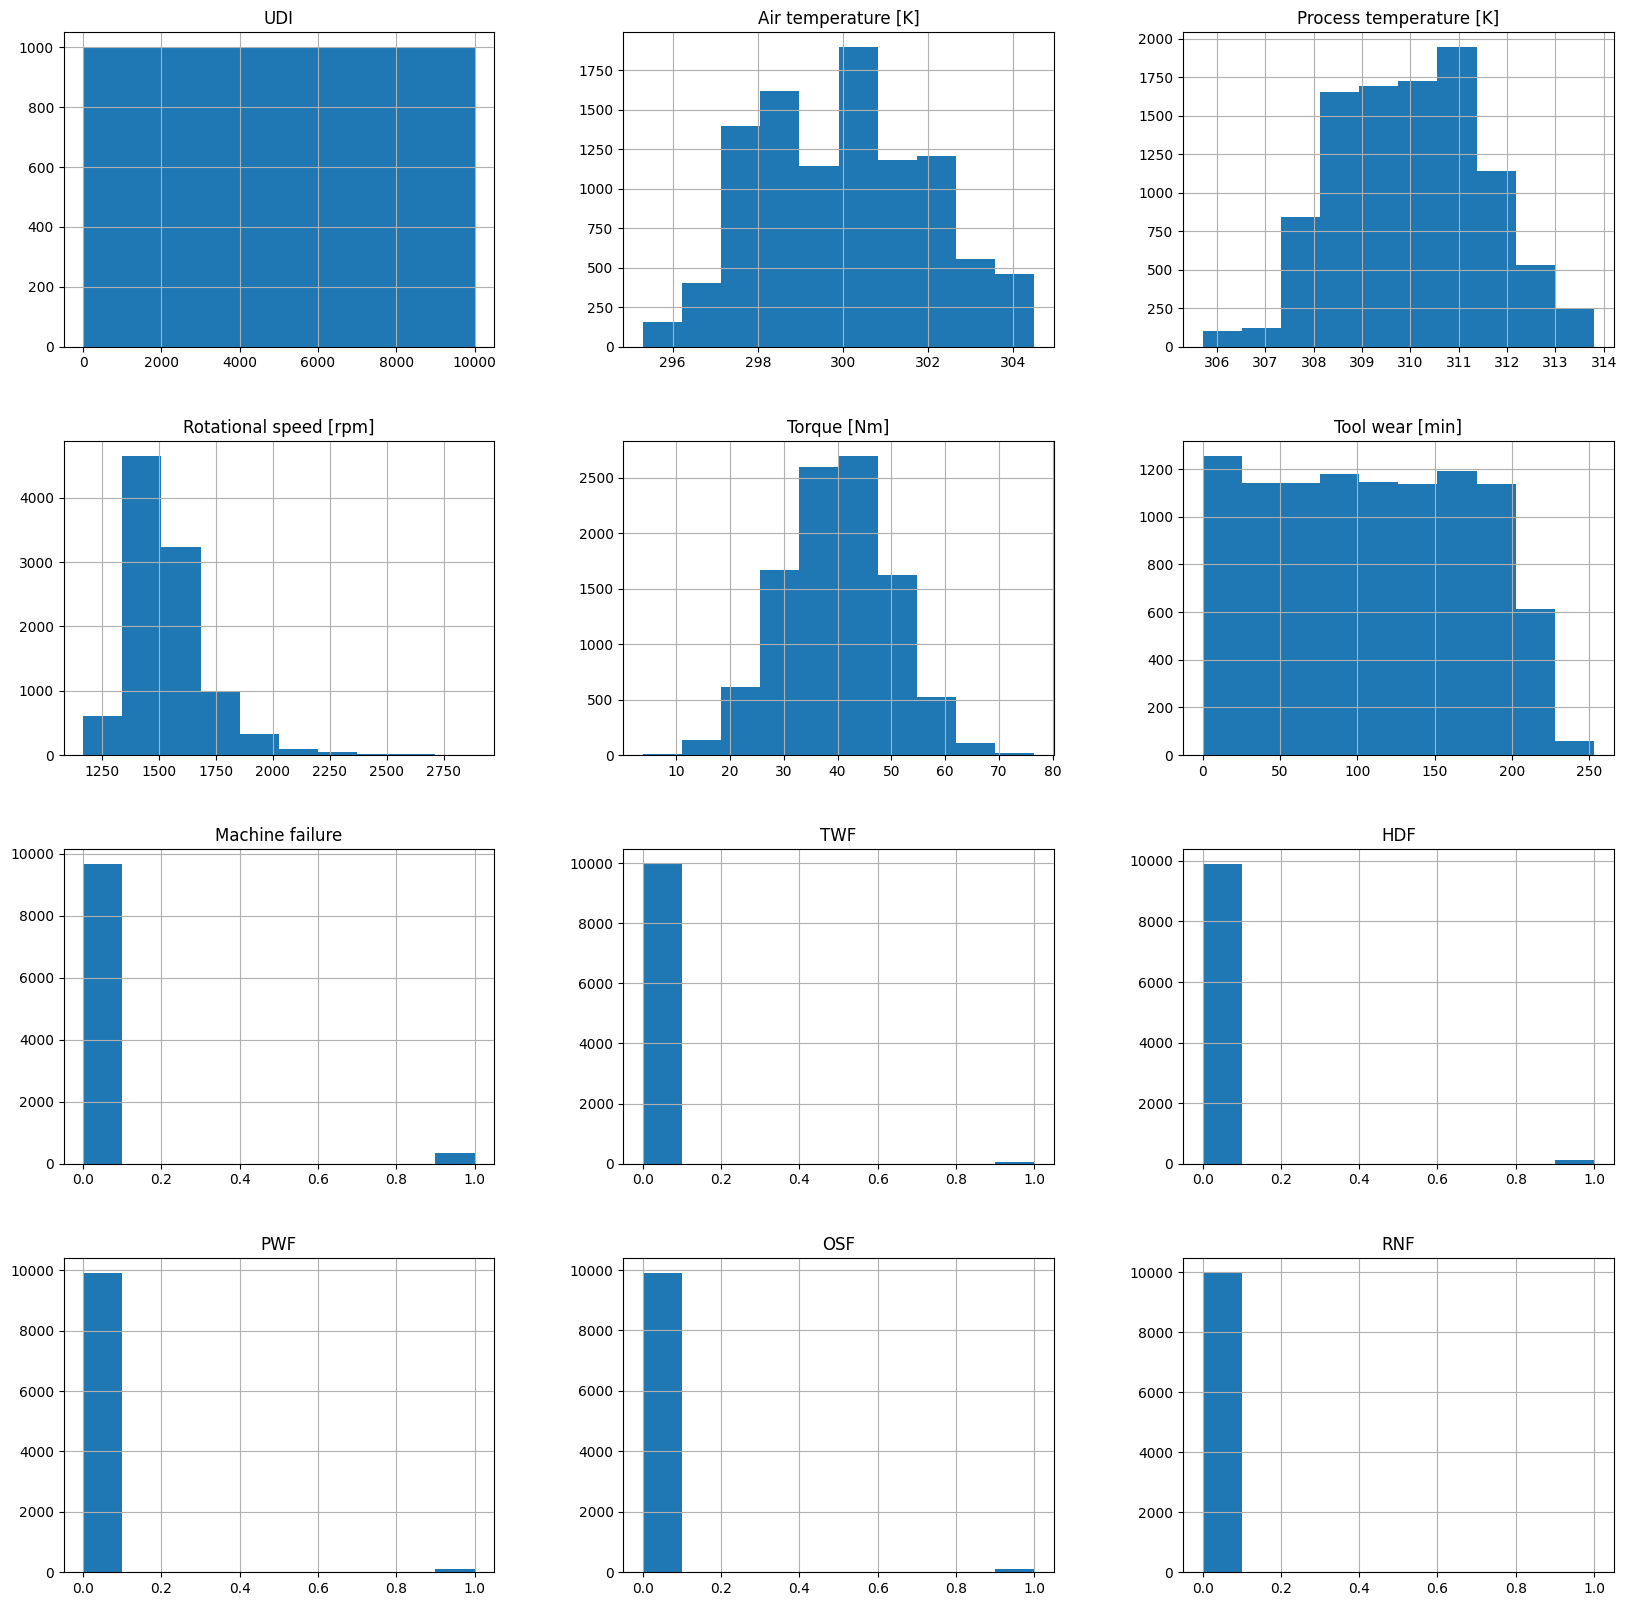

In [6]:
df.hist(figsize=(20, 20))

In [7]:
df['Machine failure'].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

<Axes: xlabel='Machine failure', ylabel='count'>

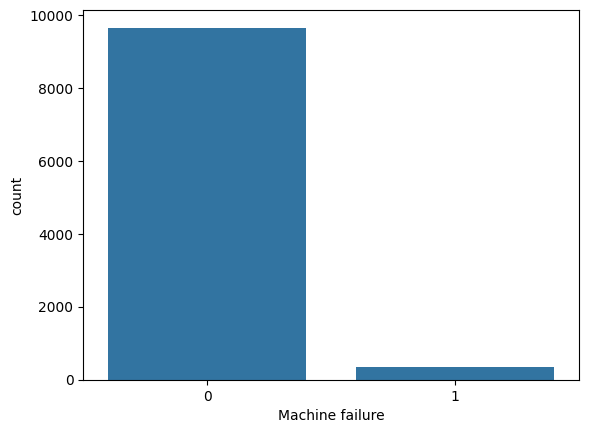

In [8]:
sns.countplot(x='Machine failure', data=df)

In [9]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='str')

In [10]:
failture_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

def classify_failure_type(row):
    for name in failture_cols:
        if row[name] == 1:
            return name
    return "No failure"

In [11]:
df['Failure type'] = df.apply(classify_failure_type, axis=1)

In [12]:
df['Failure type']

0       No failure
1       No failure
2       No failure
3       No failure
4       No failure
           ...    
9995    No failure
9996    No failure
9997    No failure
9998    No failure
9999    No failure
Name: Failure type, Length: 10000, dtype: str

<Axes: xlabel='Failure type', ylabel='count'>

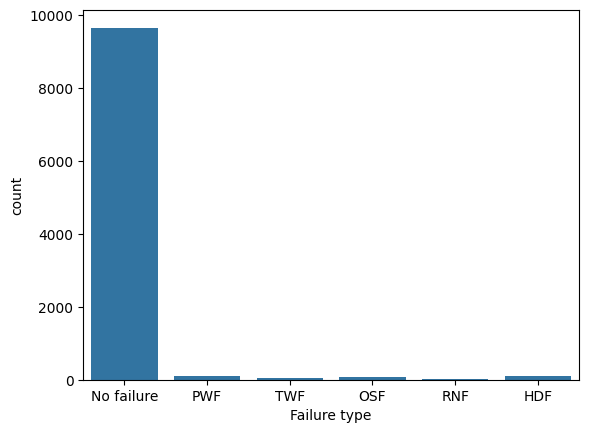

In [13]:
sns.countplot(x='Failure type', data=df)

<Axes: xlabel='Type', ylabel='count'>

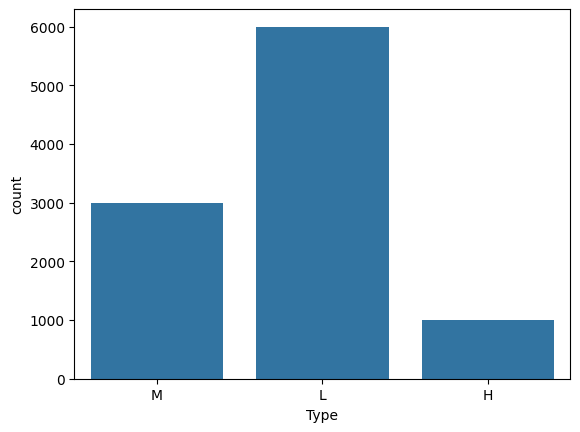

In [14]:
sns.countplot(x = 'Type', data=df)

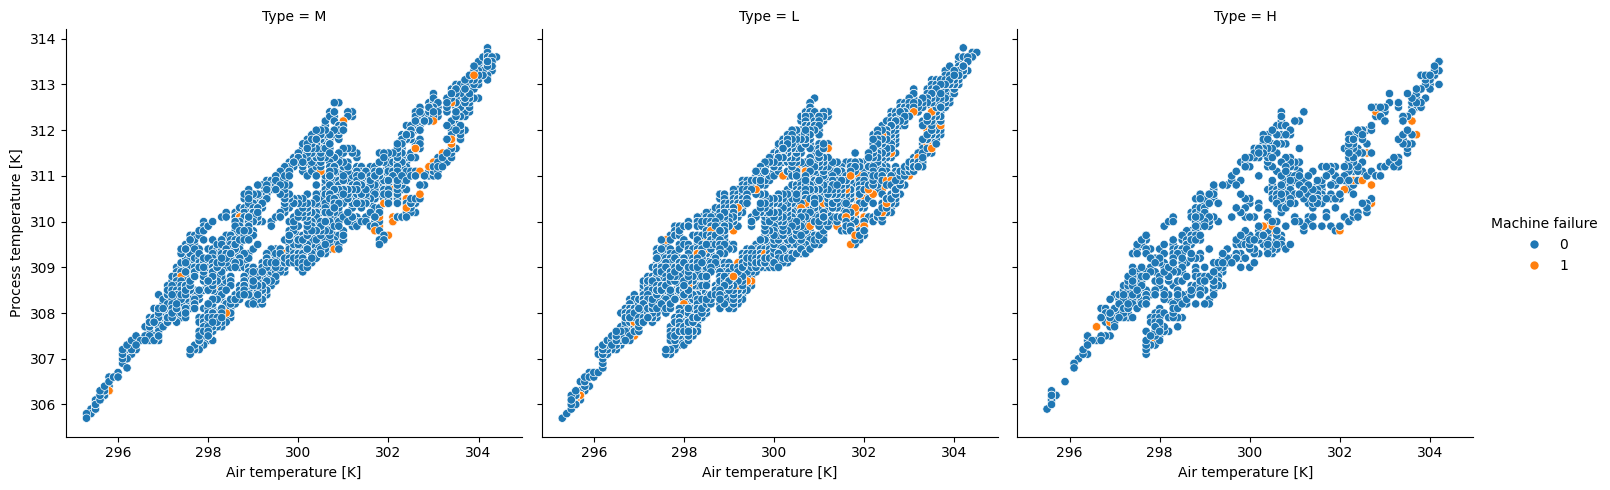

In [15]:
sns.relplot(x='Air temperature [K]', y='Process temperature [K]', hue='Machine failure', col="Type" , data=df)

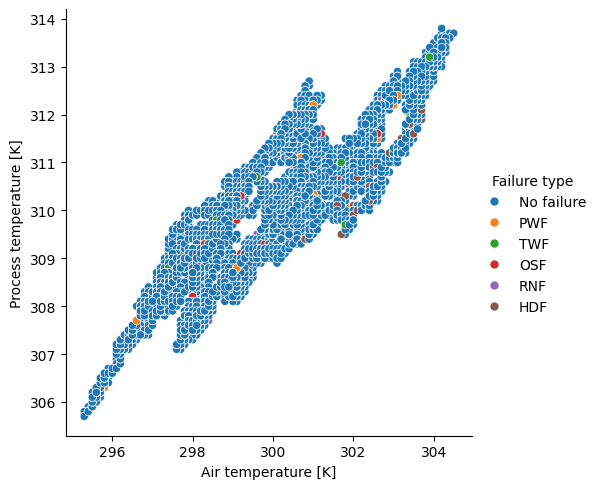

In [16]:
sns.relplot(x='Air temperature [K]', y='Process temperature [K]', hue='Failure type', data=df)

In [17]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF',
       'Failure type'],
      dtype='str')

Text(0.5, 1.0, 'Scatter plot of Air Temperature vs Process Temperature')

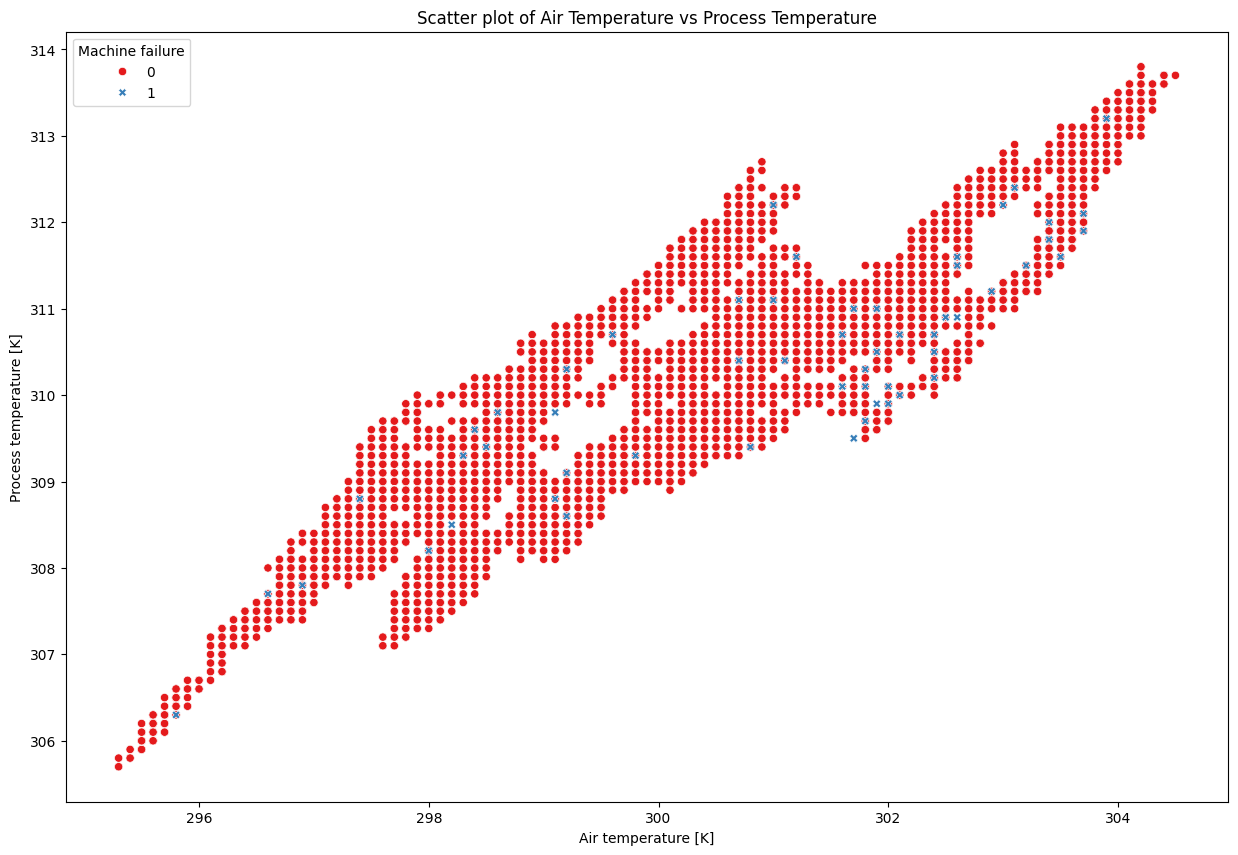

In [18]:
fig, ax  = plt.subplots(figsize = (15, 10))
sns.scatterplot(
    x = 'Air temperature [K]', y = 'Process temperature [K]',
    hue = 'Machine failure', style = 'Machine failure',
    palette='Set1', data=df
)
plt.title('Scatter plot of Air Temperature vs Process Temperature')

# Observation: Linear relationship. More machine failures when Air and Process temp gets too high

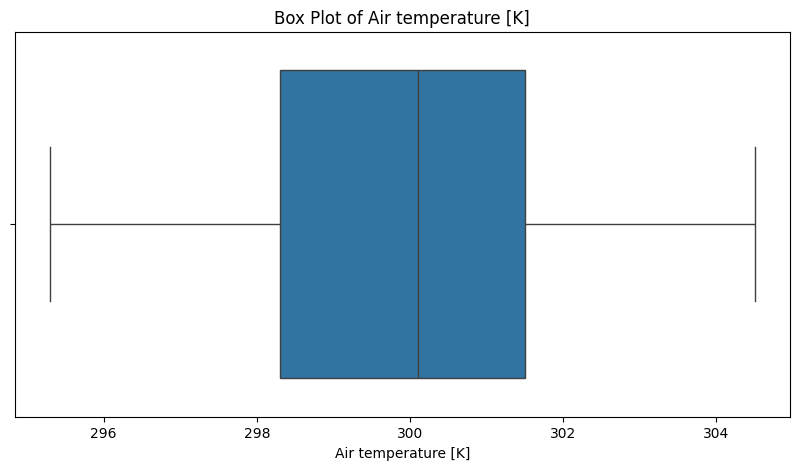

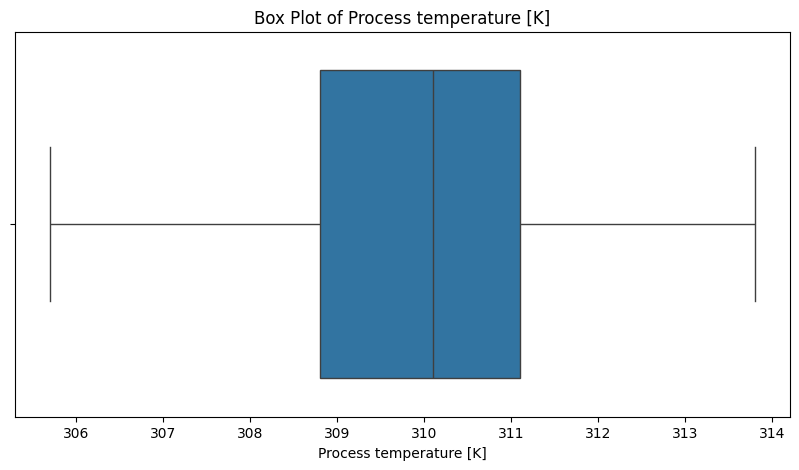

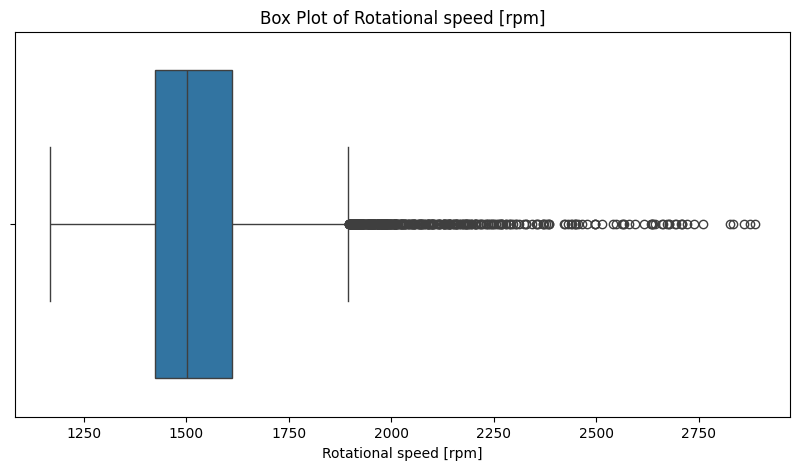

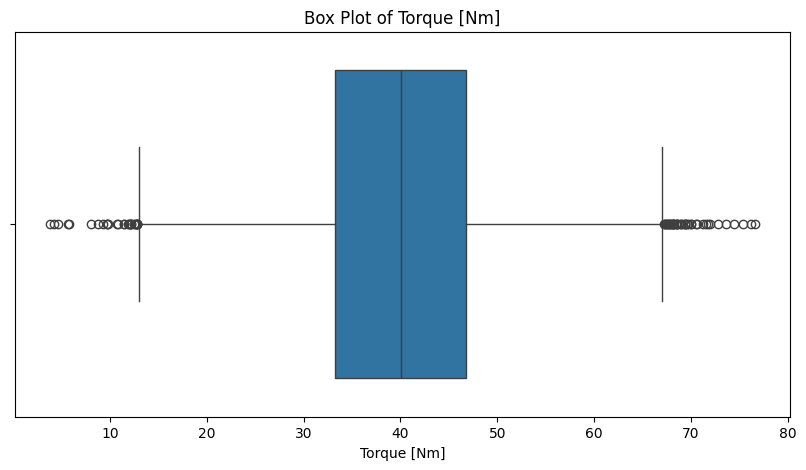

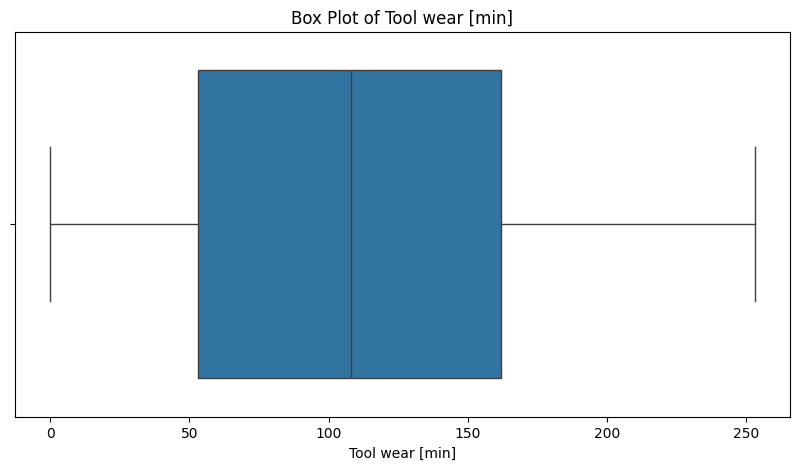

In [19]:
## Outlier detection - Boxplot

sensor_cols = ['Air temperature [K]', 'Process temperature [K]',
               'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

for col in sensor_cols:
    fig, ax = plt.subplots(figsize = (10, 5))
    sns.boxplot(x = df[col])
    plt.title(f'Box Plot of {col}')
    plt.show()

### Narrative
* Torque and Rotation Speed had more outliers or poiints outside their normal range 

## Feature Engineer & ML

In [20]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF',
       'Failure type'],
      dtype='str')

In [21]:
df['Type'].unique()

<StringArray>
['M', 'L', 'H']
Length: 3, dtype: str

In [22]:
df['Type'] = df['Type'].map({'L': 0, 'M': 1, 'H':2 })

In [23]:
df['Type']

0       1
1       0
2       0
3       0
4       0
       ..
9995    1
9996    2
9997    1
9998    2
9999    1
Name: Type, Length: 10000, dtype: int64

In [24]:
X = df.drop(labels=['UDI', 'Product ID', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF',
       'Failure type'], axis = 1)
y = df['Machine failure']

In [25]:
X.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,1,298.1,308.6,1551,42.8,0
1,0,298.2,308.7,1408,46.3,3
2,0,298.1,308.5,1498,49.4,5
3,0,298.2,308.6,1433,39.5,7
4,0,298.2,308.7,1408,40.0,9


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [31]:
# Build model

def build_model(classifier, X_train, y_train):
    classifier.fit(X_train, y_train)
    return classifier

In [32]:
# Randomforst

rf = RandomForestClassifier(n_estimators = 100, random_state = 42)
rf_clf = build_model(rf, X_train, y_train)

In [39]:
y_predict_test = rf_clf.predict(X_test)
y_predict_train = rf_clf.predict(X_train)

In [40]:
cm = confusion_matrix(y_pred=y_predict_test, y_true=y_test)
print(classification_report(y_pred=y_predict_test, y_true=y_test))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1939
           1       0.86      0.59      0.70        61

    accuracy                           0.98      2000
   macro avg       0.92      0.79      0.85      2000
weighted avg       0.98      0.98      0.98      2000



<Axes: >

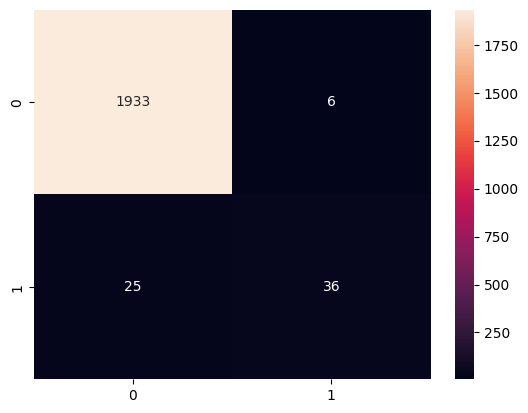

In [41]:
sns.heatmap(data = cm, annot=True, fmt='d')

In [42]:
print(classification_report(y_pred=y_predict_train, y_true=y_train))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7722
           1       1.00      1.00      1.00       278

    accuracy                           1.00      8000
   macro avg       1.00      1.00      1.00      8000
weighted avg       1.00      1.00      1.00      8000



<Axes: >

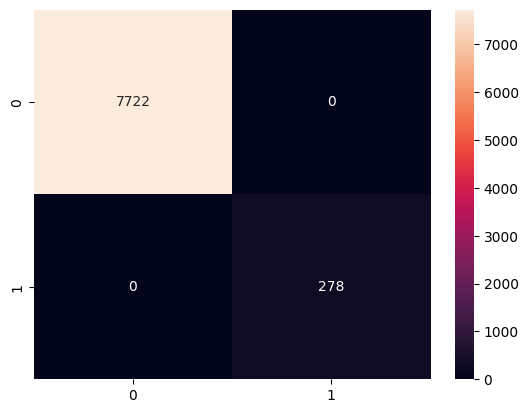

In [43]:
cm_train = confusion_matrix(y_pred=y_predict_train, y_true=y_train)
sns.heatmap(data = cm_train, annot=True, fmt='d')